In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO

In [2]:
record = SeqIO.read("chr1.fasta", "fasta")
seq = str(record.seq[:100000]).upper()

Реализация функции compute_cpg_ratio(window):

In [3]:
def compute_cpg_ratio(window):
    """
    Вычисляет:
    - P(CG) - частота динуклеотида CG
    - P(C) и P(G) - частоты отдельных нуклеотидов
    - R(CG) = P(CG) / (P(C) * P(G))
    - GC% - процент G и C
    """
    if len(window) < 2:
        return 0, 0, 0
    
    cg_count = window.count('CG')
    c_count = window.count('C')
    g_count = window.count('G')
    
    p_cg = cg_count / (len(window) - 1)
    p_c = c_count / len(window)
    p_g = g_count / len(window)
    
    if p_c * p_g > 0:
        r_cg = p_cg / (p_c * p_g)
    else:
        r_cg = 0
    
    gc_percent = (c_count + g_count) / len(window)
    
    return r_cg, gc_percent, p_cg

Пройдемся по посл-ти скользящим окном в 200 нуклеотидов:

In [5]:
window_size = 200
step = 1  # шаг сканирования

positions = []
r_cg_values = []
gc_values = []
cpg_islands = []

for i in range(0, len(seq) - window_size + 1, step):
    window = seq[i:i+window_size]
    r_cg, gc, _ = compute_cpg_ratio(window)
    
    positions.append(i)
    r_cg_values.append(r_cg)
    gc_values.append(gc)
    
    if r_cg > 0.6 and gc > 0.5: #отмечаем участки с R(CG) > 0.6 и GC% > 50%
        cpg_islands.append((i, i+window_size, r_cg, gc))

Выведем координаты найденных CpG островков:

In [7]:
print("\nКоординаты CpG островков (start, end, R(CG), GC%):")
for island in cpg_islands:  # первые 20
    print(f"{island[0]:6d} -{island[1]:6d}  R={island[2]:.3f}  GC={island[3]:.3f}")


Координаты CpG островков (start, end, R(CG), GC%):
 10270 - 10470  R=1.844  GC=0.550
 10271 - 10471  R=1.844  GC=0.550
 10272 - 10472  R=1.861  GC=0.550
 10273 - 10473  R=1.241  GC=0.555
 10274 - 10474  R=1.241  GC=0.555
 10275 - 10475  R=1.241  GC=0.555
 10276 - 10476  R=1.241  GC=0.555
 10277 - 10477  R=1.241  GC=0.555
 10278 - 10478  R=1.241  GC=0.555
 10279 - 10479  R=1.241  GC=0.555
 10280 - 10480  R=1.229  GC=0.560
 10281 - 10481  R=1.229  GC=0.560
 10282 - 10482  R=0.931  GC=0.560
 10283 - 10483  R=0.931  GC=0.560
 10284 - 10484  R=0.931  GC=0.560
 10285 - 10485  R=1.117  GC=0.565
 10286 - 10486  R=0.931  GC=0.570
 10287 - 10487  R=0.922  GC=0.575
 10288 - 10488  R=0.922  GC=0.575
 10289 - 10489  R=0.922  GC=0.575
 10290 - 10490  R=1.064  GC=0.575
 10291 - 10491  R=1.064  GC=0.575
 10292 - 10492  R=1.054  GC=0.580
 10293 - 10493  R=1.044  GC=0.585
 10294 - 10494  R=1.153  GC=0.585
 10295 - 10495  R=1.153  GC=0.585
 10296 - 10496  R=1.153  GC=0.585
 10297 - 10497  R=1.153  GC=0.

Теперь визулизируем результаты:

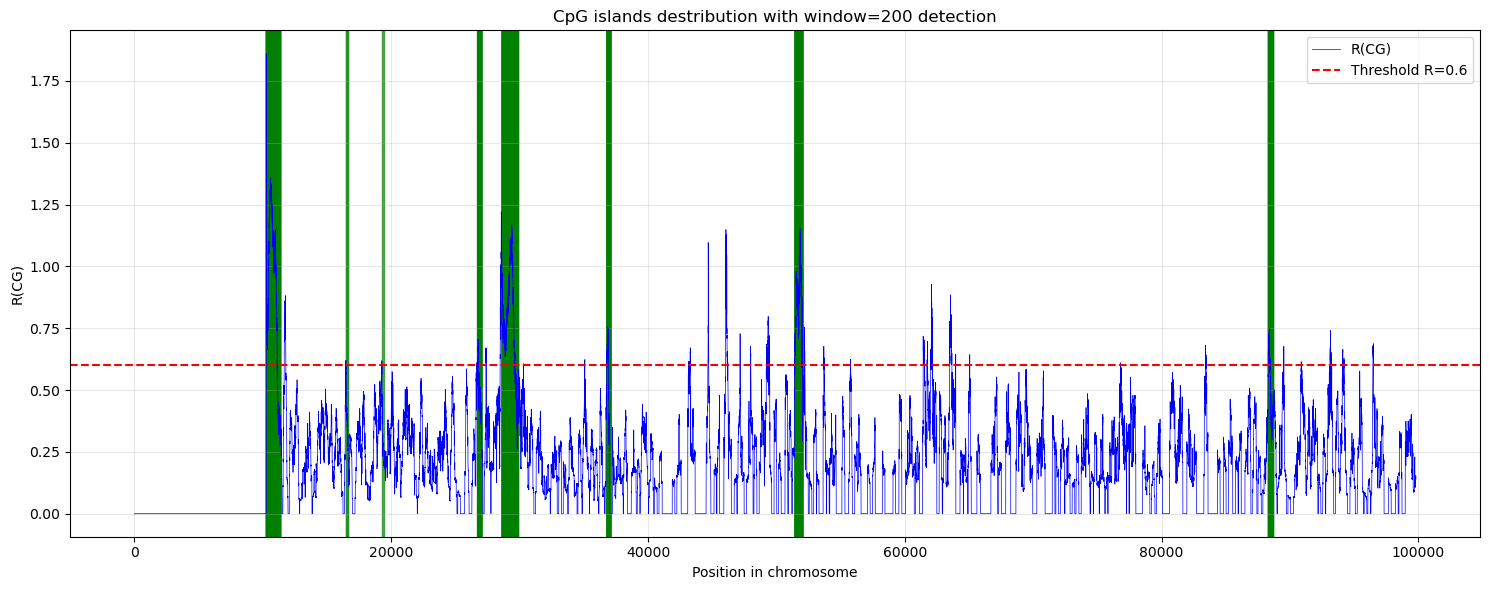

In [10]:
plt.figure(figsize=(15, 6))

plt.plot(positions, r_cg_values, 'b-', linewidth=0.5, label='R(CG)')
plt.axhline(y=0.6, color='r', linestyle='--', label='Threshold R=0.6')

# Подсветка CpG островков
for start, end, _, _ in cpg_islands:
    plt.axvspan(start, end, alpha=0.2, color='green')

plt.xlabel('Position in chromosome')
plt.ylabel('R(CG)')
plt.title('CpG islands destribution with window=200 detection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()